# Racing Telemetry — Exploratory Data Analysis

**Dataset:** `telemetry-rio-5-laps.csv`  
**Source:** UDP telemetry from a racing simulator (Forza Motorsport protocol)  
**Track:** Rio de Janeiro circuit — 5 laps, single car  

## Objectives
1. Understand the structure and quality of the dataset  
2. Reconstruct the track map from position data  
3. Compare lap performance across 4 racing laps  
4. Analyze vehicle dynamics: speed, engine, tires, and driver inputs  
5. Identify key correlations to guide future modeling  

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import pearsonr
import warnings

warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a1a',
    'axes.edgecolor':   '#444444',
    'axes.labelcolor':  '#cccccc',
    'xtick.color':      '#888888',
    'ytick.color':      '#888888',
    'text.color':       '#cccccc',
    'grid.color':       '#2a2a2a',
    'grid.linewidth':   0.6,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'legend.facecolor': '#1a1a1a',
    'legend.edgecolor': '#444444',
    'figure.dpi':       110,
})

LAP_COLORS = {
    1: '#00d4ff',
    2: '#ff6b35',
    3: '#7fff00',
    4: '#ff00aa',
}

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Data

In [2]:
df = pd.read_csv('telemetry-rio-5-laps.csv', index_col=0)

# Convert boolean-as-string columns to actual booleans
bool_cols = [c for c in df.columns if 'rumble' in c or 'puddle' in c]
for col in [c for c in df.columns if 'rumble' in c]:
    df[col] = df[col].map({'True': True, 'False': False})

# Derived columns useful throughout the EDA
df['throttle_pct'] = df['acceleration'] / 255 * 100   # 0–100%
df['brake_pct']    = df['brake']        / 255 * 100
df['speed_kmh']    = df['speed'] * 3.6
df['power_kw']     = df['power'] / 1000

# Keep only racing laps (exclude lap 0 = warm-up/pre-race)
df_race = df[df['lap_number'] >= 1].copy()

print(f'Total rows: {len(df):,}')
print(f'Racing laps rows: {len(df_race):,}')
print(f'Columns: {df.shape[1]}')

Total rows: 94,519
Racing laps rows: 75,090
Columns: 76


## 3. Dataset Structure

In [3]:
print('=== dtypes ===')
print(df.dtypes.value_counts())
print()
print('=== Missing values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values.')
print()
print('=== Duplicate rows ===')
print(f'{df.duplicated().sum()} duplicate rows')

=== dtypes ===
float64    62
int64      10
object      4
Name: count, dtype: int64

=== Missing values ===
wheel_on_rumble_strip_front_left     94519
wheel_on_rumble_strip_front_right    94519
wheel_on_rumble_strip_rear_left      94519
wheel_on_rumble_strip_rear_right     94519
dtype: int64

=== Duplicate rows ===


0 duplicate rows


In [4]:
# Sampling frequency
mean_interval_ms = df['since_last_ns'].mean() / 1e6
print(f'Mean sampling interval: {mean_interval_ms:.2f} ms  (~{1000/mean_interval_ms:.0f} Hz)')

# Lap breakdown
lap_counts = df.groupby('lap_number').size().reset_index(name='samples')
lap_counts['duration_s'] = df.groupby('lap_number')['since_last_ns'].sum().values / 1e9
print()
print(lap_counts.to_string(index=False))

Mean sampling interval: 8.33 ms  (~120 Hz)

 lap_number  samples  duration_s
          0    19429  161.927448
          1    18978  158.161795
          2    18682  155.703453
          3    19058  158.837472
          4    18372  153.119742


In [5]:
# Core statistics for main variables
key_cols = ['speed_kmh', 'current_engine_rpm', 'throttle_pct', 'brake_pct',
            'gear', 'fuel', 'tire_temp_front_left', 'tire_temp_rear_left']
df_race[key_cols].describe().round(2)

,speed_kmh,current_engine_rpm,throttle_pct,brake_pct,gear,fuel,tire_temp_front_left,tire_temp_rear_left
count,75090.00,75090.00,75090.00,75090.00,75090.00,75090.00,75090.00,75090.00
mean,140.29,5524.82,68.09,10.97,3.33,0.79,213.51,213.15
std,38.34,1213.56,40.71,27.64,0.73,0.08,4.70,7.64
min,36.19,1409.79,0.00,0.00,1.00,0.64,207.28,209.41
25%,110.43,4640.84,24.71,0.00,3.00,0.71,210.51,210.42
50%,141.73,5610.16,94.51,0.00,3.00,0.79,212.42,211.38
75%,171.84,6469.38,100.00,0.00,4.00,0.86,215.42,213.37
max,224.90,8031.25,100.00,100.00,4.00,0.93,259.39,309.83


## 4. Track Map

Reconstructed from `position_x` and `position_z` (the horizontal plane in this coordinate system). Colored by speed to reveal braking zones and acceleration points.

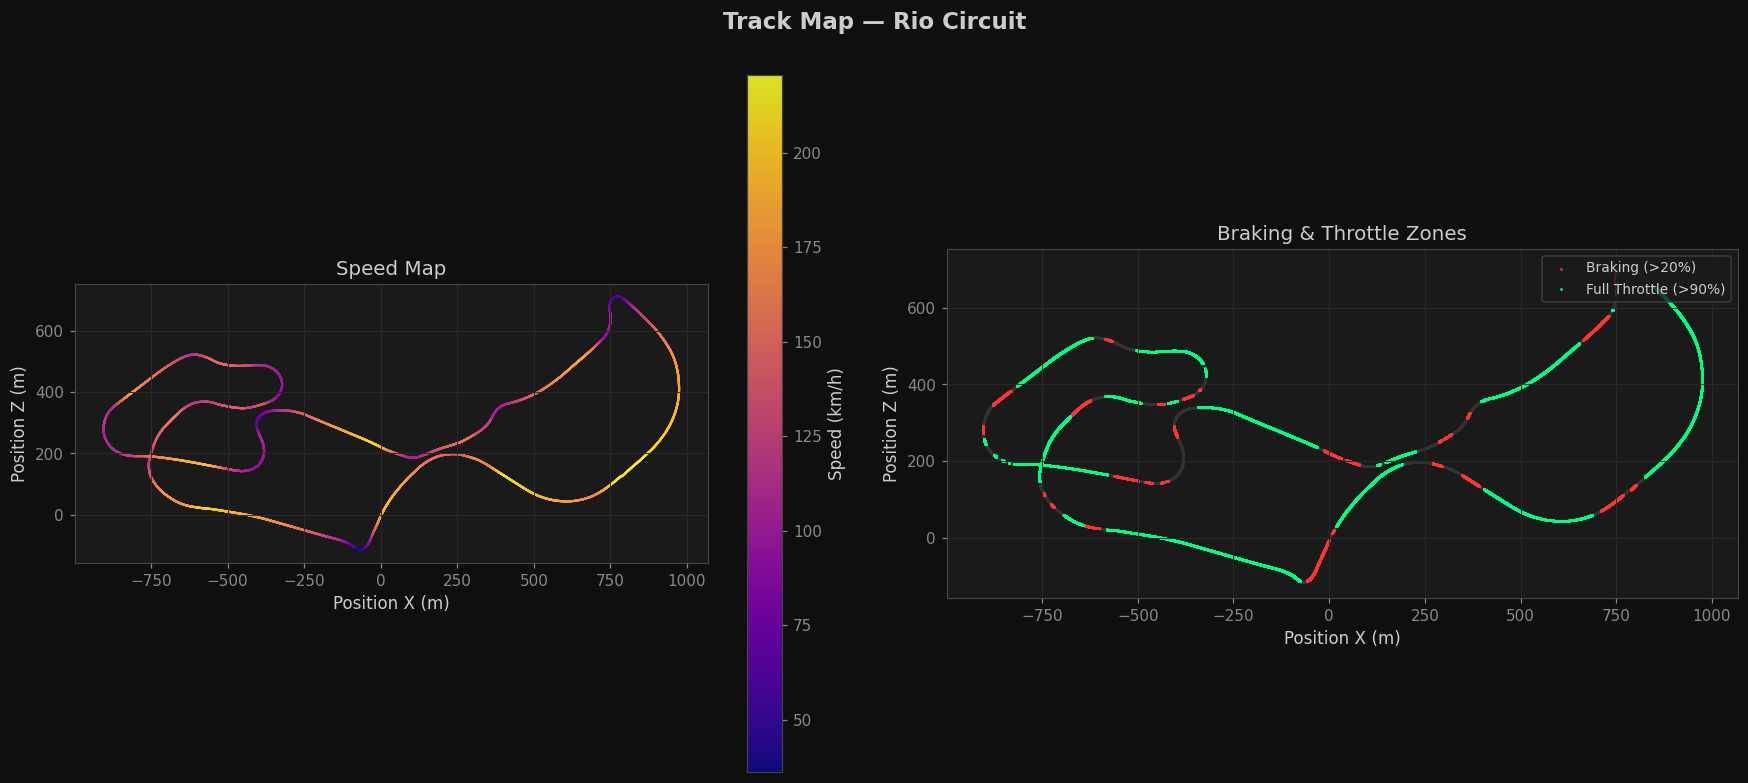

In [6]:
lap1 = df_race[df_race['lap_number'] == 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Track Map — Rio Circuit', fontsize=15, fontweight='bold', y=1.01)

# ── Left: speed heatmap ───────────────────────────────────────────────────────
ax = axes[0]
sc = ax.scatter(
    lap1['position_x'], lap1['position_z'],
    c=lap1['speed_kmh'], cmap='plasma',
    s=2, linewidths=0, alpha=0.9
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Speed (km/h)')
ax.set_title('Speed Map')
ax.set_xlabel('Position X (m)')
ax.set_ylabel('Position Z (m)')
ax.set_aspect('equal')
ax.grid(True)

# ── Right: throttle/brake zones ───────────────────────────────────────────────
ax = axes[1]

# Base track in grey
ax.scatter(lap1['position_x'], lap1['position_z'],
           c='#333333', s=2, linewidths=0)

# Braking zones (brake > 20%)
braking = lap1[lap1['brake_pct'] > 20]
ax.scatter(braking['position_x'], braking['position_z'],
           c='#ff3333', s=4, label='Braking (>20%)', linewidths=0, alpha=0.8)

# Full throttle (throttle > 90%)
full_gas = lap1[lap1['throttle_pct'] > 90]
ax.scatter(full_gas['position_x'], full_gas['position_z'],
           c='#00ff88', s=4, label='Full Throttle (>90%)', linewidths=0, alpha=0.8)

ax.set_title('Braking & Throttle Zones')
ax.set_xlabel('Position X (m)')
ax.set_ylabel('Position Z (m)')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig('track_map.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 5. Lap Analysis

Comparing the 4 racing laps by time and speed profile.

In [7]:
# Lap times: last recorded current_lap_time before lap_number increments
lap_times = (
    df_race.groupby('lap_number')['current_lap_time']
    .max()
    .reset_index()
    .rename(columns={'current_lap_time': 'lap_time_s'})
)
lap_times['lap_time_str'] = lap_times['lap_time_s'].apply(
    lambda s: f"{int(s//60)}:{s%60:06.3f}"
)
best_idx = lap_times['lap_time_s'].idxmin()

print('Lap times:')
for _, row in lap_times.iterrows():
    flag = '  ◀ BEST' if _ == best_idx else ''
    print(f"  Lap {int(row['lap_number'])}: {row['lap_time_str']}{flag}")

Lap times:
  Lap 1: 2:38.154
  Lap 2: 2:35.698
  Lap 3: 2:38.830
  Lap 4: 2:33.113  ◀ BEST


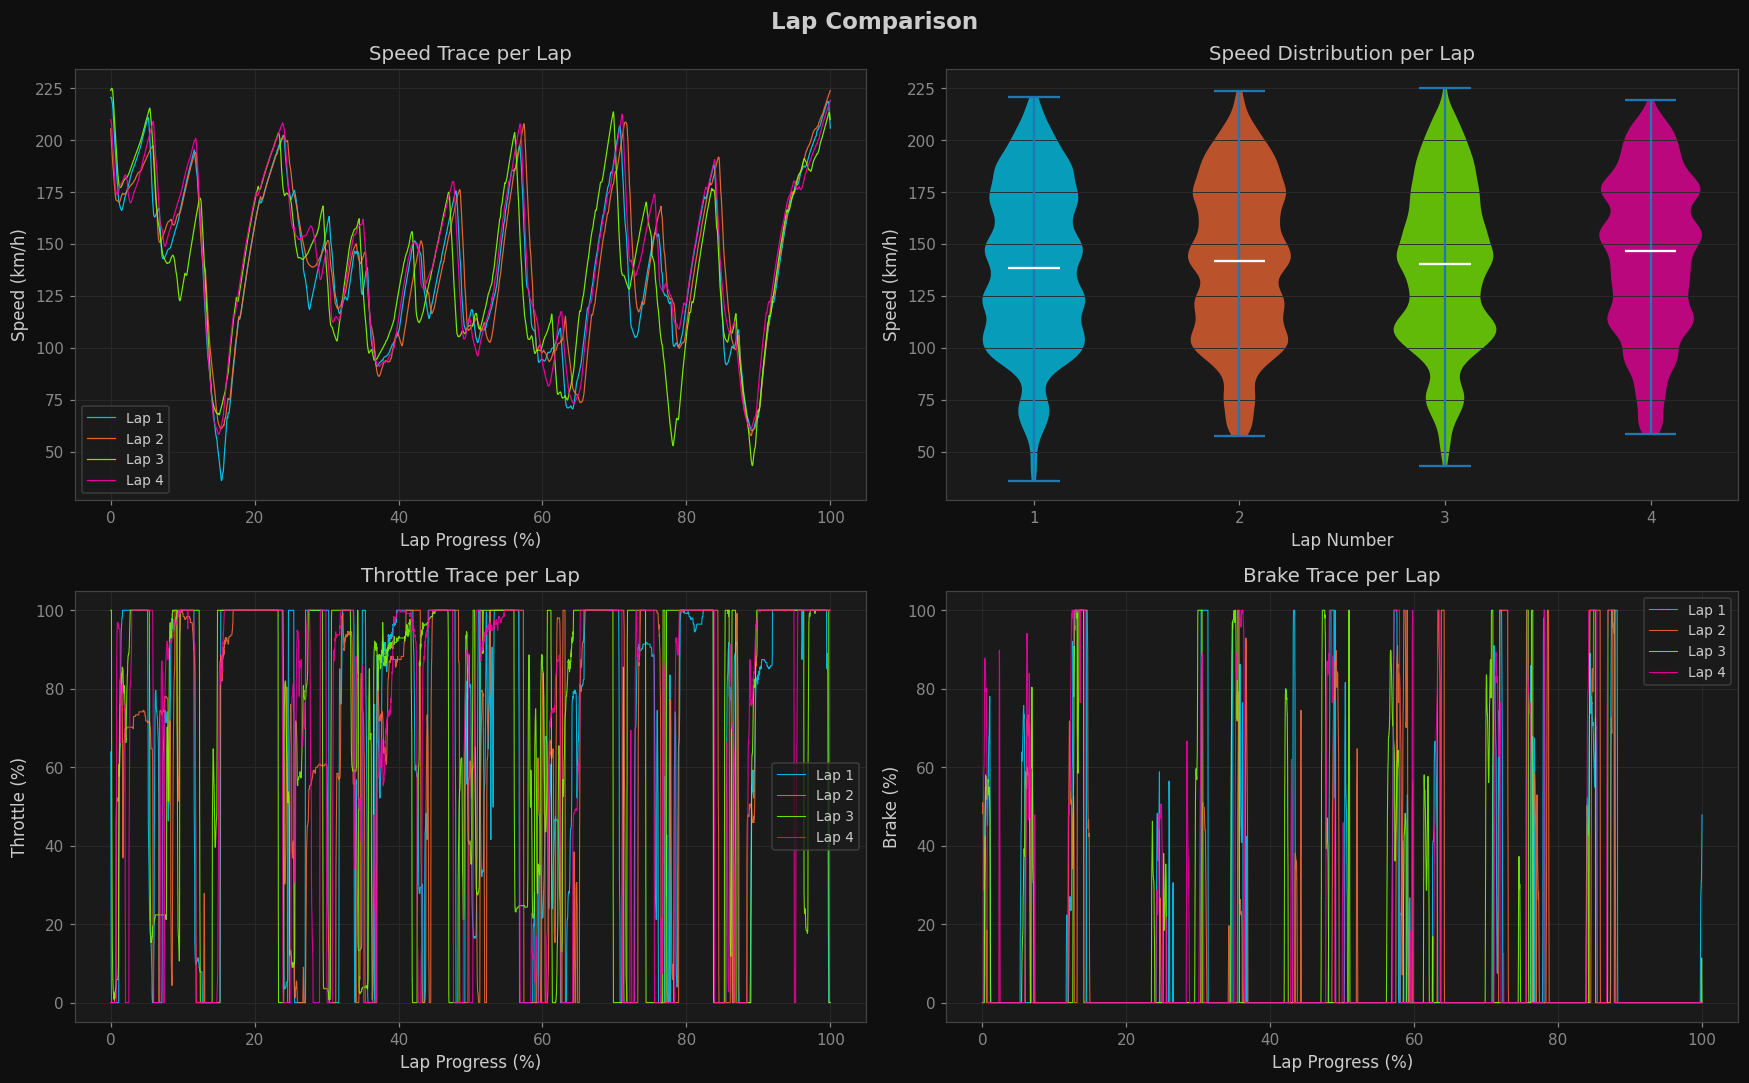

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Lap Comparison', fontsize=15, fontweight='bold')

lap_nums = sorted(df_race['lap_number'].unique())

# Normalise distance within each lap to 0–100% for cross-lap comparison
def normalise_lap_distance(lap_df):
    d = lap_df['current_lap_time'].values
    d_norm = (d - d.min()) / (d.max() - d.min() + 1e-9) * 100
    return d_norm

# ── Speed trace per lap ───────────────────────────────────────────────────────
ax = axes[0, 0]
for lap in lap_nums:
    ldf = df_race[df_race['lap_number'] == lap]
    t_norm = normalise_lap_distance(ldf)
    ax.plot(t_norm, ldf['speed_kmh'].values,
            color=LAP_COLORS[lap], lw=0.8, alpha=0.9, label=f'Lap {lap}')
ax.set_xlabel('Lap Progress (%)')
ax.set_ylabel('Speed (km/h)')
ax.set_title('Speed Trace per Lap')
ax.legend(fontsize=9)
ax.grid(True)

# ── Speed distribution per lap (violin) ──────────────────────────────────────
ax = axes[0, 1]
speed_data = [df_race[df_race['lap_number'] == lap]['speed_kmh'].values for lap in lap_nums]
parts = ax.violinplot(speed_data, positions=lap_nums, showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(LAP_COLORS[lap_nums[i]])
    pc.set_alpha(0.7)
parts['cmedians'].set_color('white')
ax.set_xlabel('Lap Number')
ax.set_ylabel('Speed (km/h)')
ax.set_title('Speed Distribution per Lap')
ax.set_xticks(lap_nums)
ax.grid(True, axis='y')

# ── Throttle trace ───────────────────────────────────────────────────────────
ax = axes[1, 0]
for lap in lap_nums:
    ldf = df_race[df_race['lap_number'] == lap]
    t_norm = normalise_lap_distance(ldf)
    ax.plot(t_norm, ldf['throttle_pct'].values,
            color=LAP_COLORS[lap], lw=0.7, alpha=0.85, label=f'Lap {lap}')
ax.set_xlabel('Lap Progress (%)')
ax.set_ylabel('Throttle (%)')
ax.set_title('Throttle Trace per Lap')
ax.legend(fontsize=9)
ax.grid(True)

# ── Brake trace ──────────────────────────────────────────────────────────────
ax = axes[1, 1]
for lap in lap_nums:
    ldf = df_race[df_race['lap_number'] == lap]
    t_norm = normalise_lap_distance(ldf)
    ax.plot(t_norm, ldf['brake_pct'].values,
            color=LAP_COLORS[lap], lw=0.7, alpha=0.85, label=f'Lap {lap}')
ax.set_xlabel('Lap Progress (%)')
ax.set_ylabel('Brake (%)')
ax.set_title('Brake Trace per Lap')
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig('lap_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 6. Speed Analysis

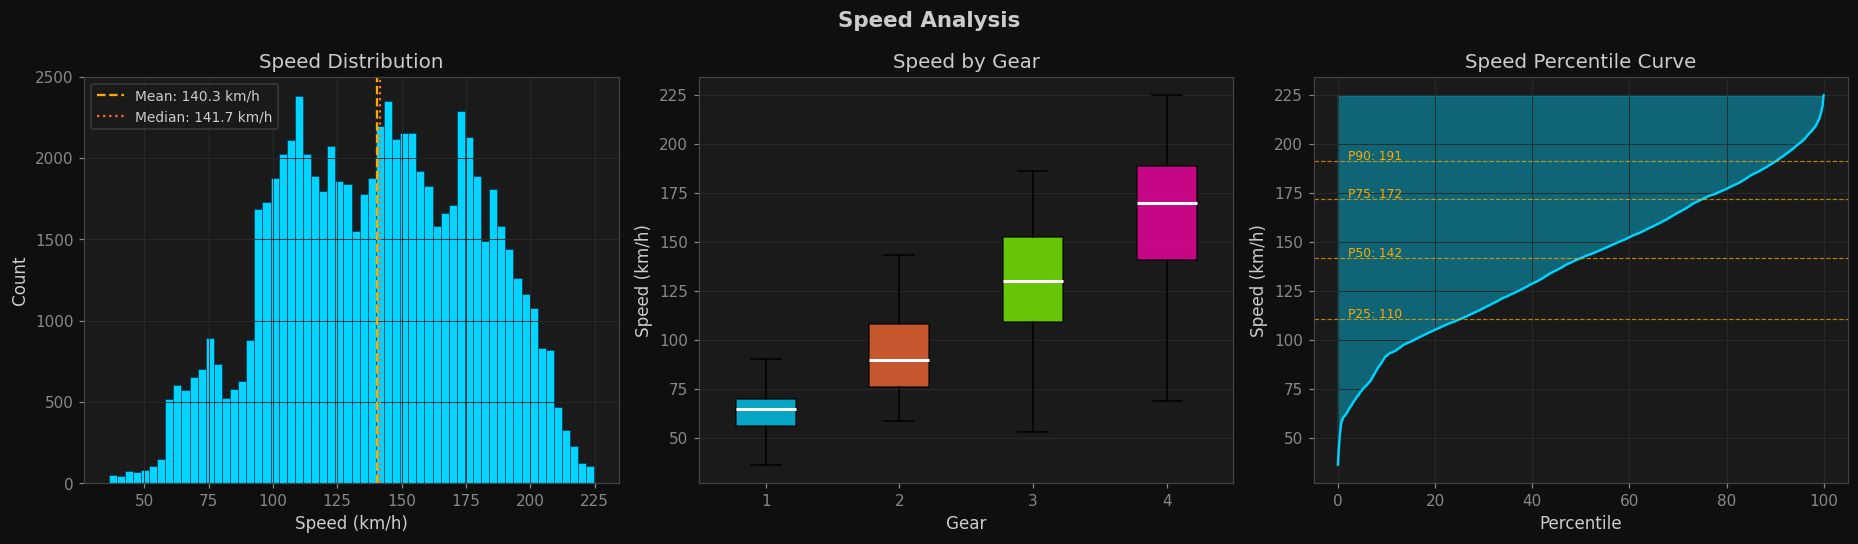

Max speed: 224.9 km/h
Min speed: 36.2 km/h
% of time above 150 km/h: 42.1%
% of time below 80 km/h (corners): 6.9%


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Speed Analysis', fontsize=14, fontweight='bold')

# ── Overall distribution ──────────────────────────────────────────────────────
ax = axes[0]
ax.hist(df_race['speed_kmh'], bins=60, color='#00d4ff', edgecolor='#003355', linewidth=0.4)
ax.axvline(df_race['speed_kmh'].mean(), color='#ffaa00', lw=1.5, linestyle='--',
           label=f"Mean: {df_race['speed_kmh'].mean():.1f} km/h")
ax.axvline(df_race['speed_kmh'].median(), color='#ff6b35', lw=1.5, linestyle=':',
           label=f"Median: {df_race['speed_kmh'].median():.1f} km/h")
ax.set_xlabel('Speed (km/h)')
ax.set_ylabel('Count')
ax.set_title('Speed Distribution')
ax.legend(fontsize=9)
ax.grid(True)

# ── Speed vs Gear ─────────────────────────────────────────────────────────────
ax = axes[1]
gear_order = sorted(df_race['gear'].unique())
gear_speed = [df_race[df_race['gear'] == g]['speed_kmh'].values for g in gear_order]
bp = ax.boxplot(gear_speed, labels=gear_order, patch_artist=True,
                medianprops=dict(color='white', linewidth=2))
colors = ['#00d4ff', '#ff6b35', '#7fff00', '#ff00aa']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xlabel('Gear')
ax.set_ylabel('Speed (km/h)')
ax.set_title('Speed by Gear')
ax.grid(True, axis='y')

# ── Speed percentile map ──────────────────────────────────────────────────────
ax = axes[2]
sorted_speeds = np.sort(df_race['speed_kmh'].values)
p = np.linspace(0, 100, len(sorted_speeds))
ax.fill_betweenx(sorted_speeds, p, alpha=0.4, color='#00d4ff')
ax.plot(p, sorted_speeds, color='#00d4ff', lw=1.5)
for pct in [25, 50, 75, 90]:
    val = np.percentile(df_race['speed_kmh'], pct)
    ax.axhline(val, color='#ffaa00', lw=0.8, linestyle='--', alpha=0.7)
    ax.text(2, val + 1, f'P{pct}: {val:.0f}', fontsize=8, color='#ffaa00')
ax.set_xlabel('Percentile')
ax.set_ylabel('Speed (km/h)')
ax.set_title('Speed Percentile Curve')
ax.grid(True)

plt.tight_layout()
plt.savefig('speed_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# Key stats
print(f"Max speed: {df_race['speed_kmh'].max():.1f} km/h")
print(f"Min speed: {df_race['speed_kmh'].min():.1f} km/h")
print(f"% of time above 150 km/h: {(df_race['speed_kmh'] > 150).mean()*100:.1f}%")
print(f"% of time below 80 km/h (corners): {(df_race['speed_kmh'] < 80).mean()*100:.1f}%")

## 7. Engine Analysis

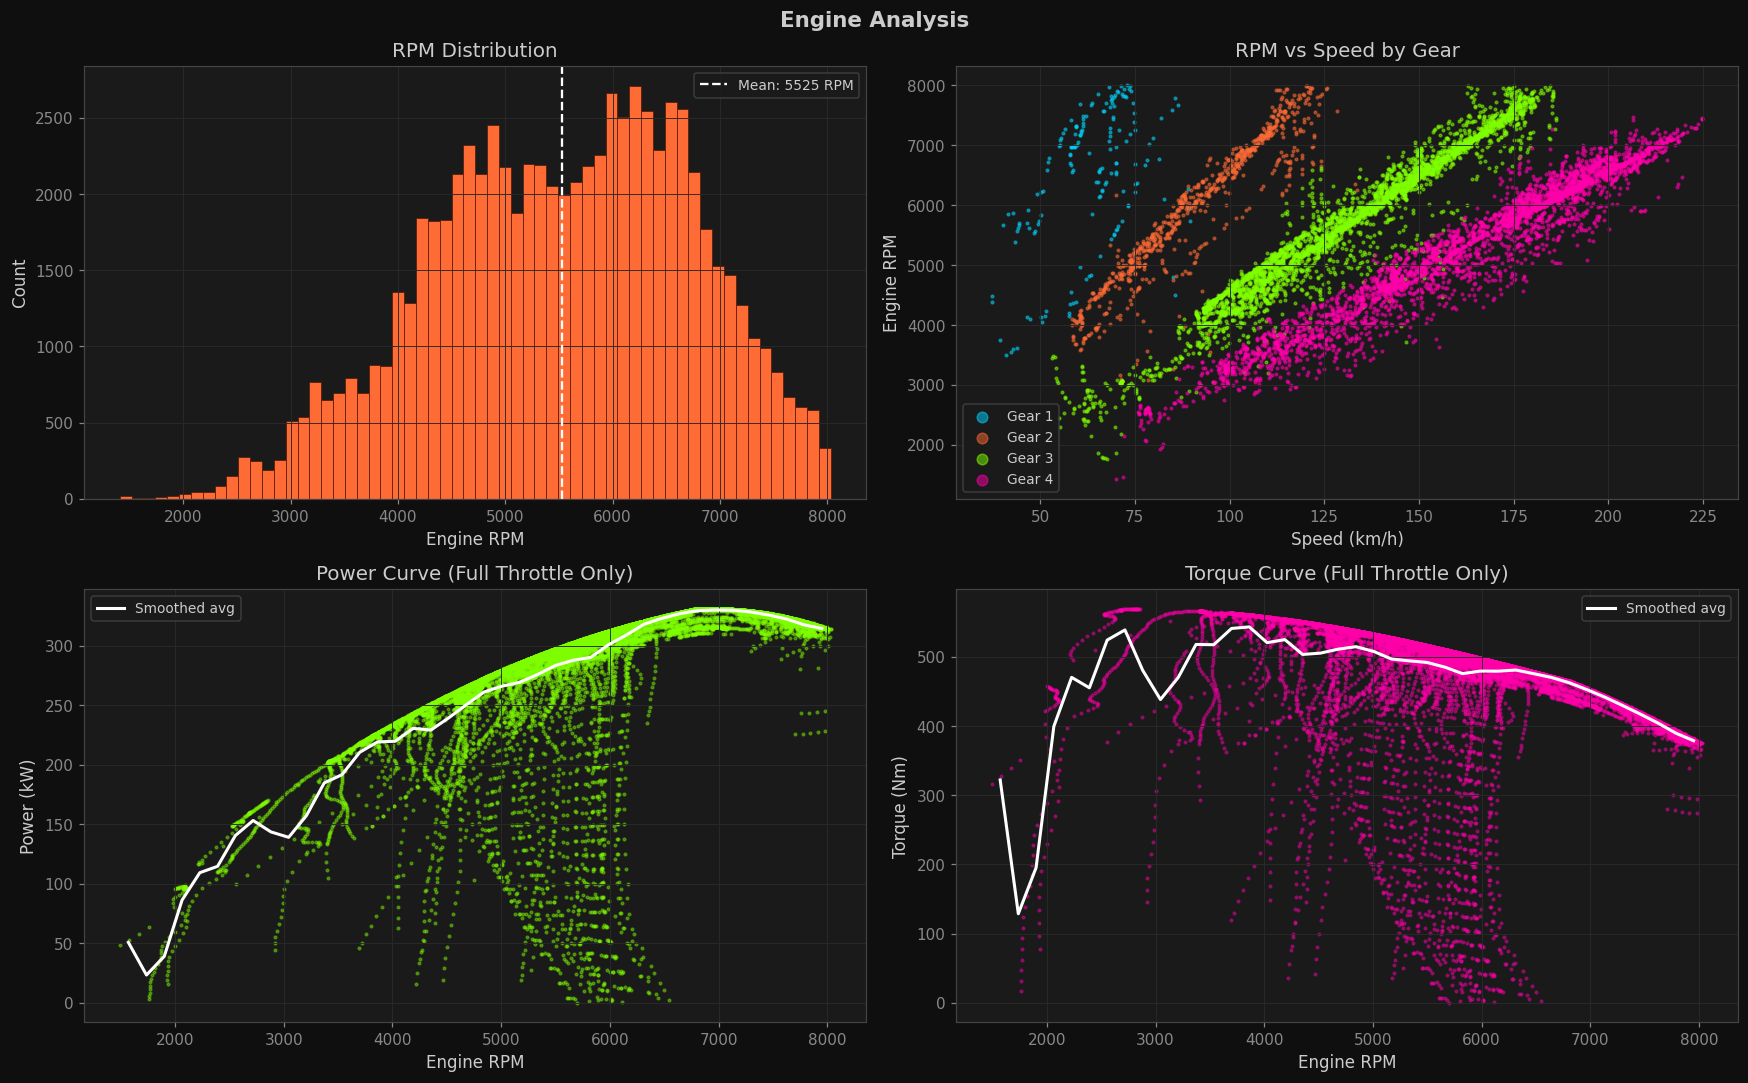

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Engine Analysis', fontsize=14, fontweight='bold')

# ── RPM distribution ──────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.hist(df_race['current_engine_rpm'], bins=60, color='#ff6b35',
        edgecolor='#441100', linewidth=0.4)
ax.axvline(df_race['current_engine_rpm'].mean(), color='white', lw=1.5, linestyle='--',
           label=f"Mean: {df_race['current_engine_rpm'].mean():.0f} RPM")
ax.set_xlabel('Engine RPM')
ax.set_ylabel('Count')
ax.set_title('RPM Distribution')
ax.legend(fontsize=9)
ax.grid(True)

# ── RPM vs Speed scatter ──────────────────────────────────────────────────────
ax = axes[0, 1]
sample = df_race.sample(min(8000, len(df_race)), random_state=42)
for g in gear_order:
    gsample = sample[sample['gear'] == g]
    ax.scatter(gsample['speed_kmh'], gsample['current_engine_rpm'],
               s=3, alpha=0.5, label=f'Gear {g}', color=colors[g-1])
ax.set_xlabel('Speed (km/h)')
ax.set_ylabel('Engine RPM')
ax.set_title('RPM vs Speed by Gear')
ax.legend(fontsize=9, markerscale=4)
ax.grid(True)

# ── Power curve (RPM vs Power) ────────────────────────────────────────────────
ax = axes[1, 0]
# Only full-throttle points to see the real power curve
full_throttle = df_race[df_race['throttle_pct'] > 95].copy()
full_throttle = full_throttle[full_throttle['power_kw'] > 0]
ax.scatter(full_throttle['current_engine_rpm'], full_throttle['power_kw'],
           s=3, alpha=0.4, color='#7fff00')
# Smoothed average
rpm_bins = pd.cut(full_throttle['current_engine_rpm'], bins=40)
smooth = full_throttle.groupby(rpm_bins, observed=True)['power_kw'].mean()
rpm_centers = [iv.mid for iv in smooth.index]
ax.plot(rpm_centers, smooth.values, color='white', lw=2, label='Smoothed avg')
ax.set_xlabel('Engine RPM')
ax.set_ylabel('Power (kW)')
ax.set_title('Power Curve (Full Throttle Only)')
ax.legend(fontsize=9)
ax.grid(True)

# ── Torque curve ──────────────────────────────────────────────────────────────
ax = axes[1, 1]
full_throttle_t = df_race[
    (df_race['throttle_pct'] > 95) & (df_race['torque'] > 0)
].copy()
ax.scatter(full_throttle_t['current_engine_rpm'], full_throttle_t['torque'],
           s=3, alpha=0.4, color='#ff00aa')
rpm_bins_t = pd.cut(full_throttle_t['current_engine_rpm'], bins=40)
smooth_t = full_throttle_t.groupby(rpm_bins_t, observed=True)['torque'].mean()
rpm_centers_t = [iv.mid for iv in smooth_t.index]
ax.plot(rpm_centers_t, smooth_t.values, color='white', lw=2, label='Smoothed avg')
ax.set_xlabel('Engine RPM')
ax.set_ylabel('Torque (Nm)')
ax.set_title('Torque Curve (Full Throttle Only)')
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig('engine_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 8. Tire Analysis

Tire temperature reveals thermal load on each corner. Slip angles reveal understeer (front slip > rear) and oversteer (rear slip > front).

Oversteer  (rear > front slip): 34.2% of samples
Understeer (front > rear slip): 65.8% of samples


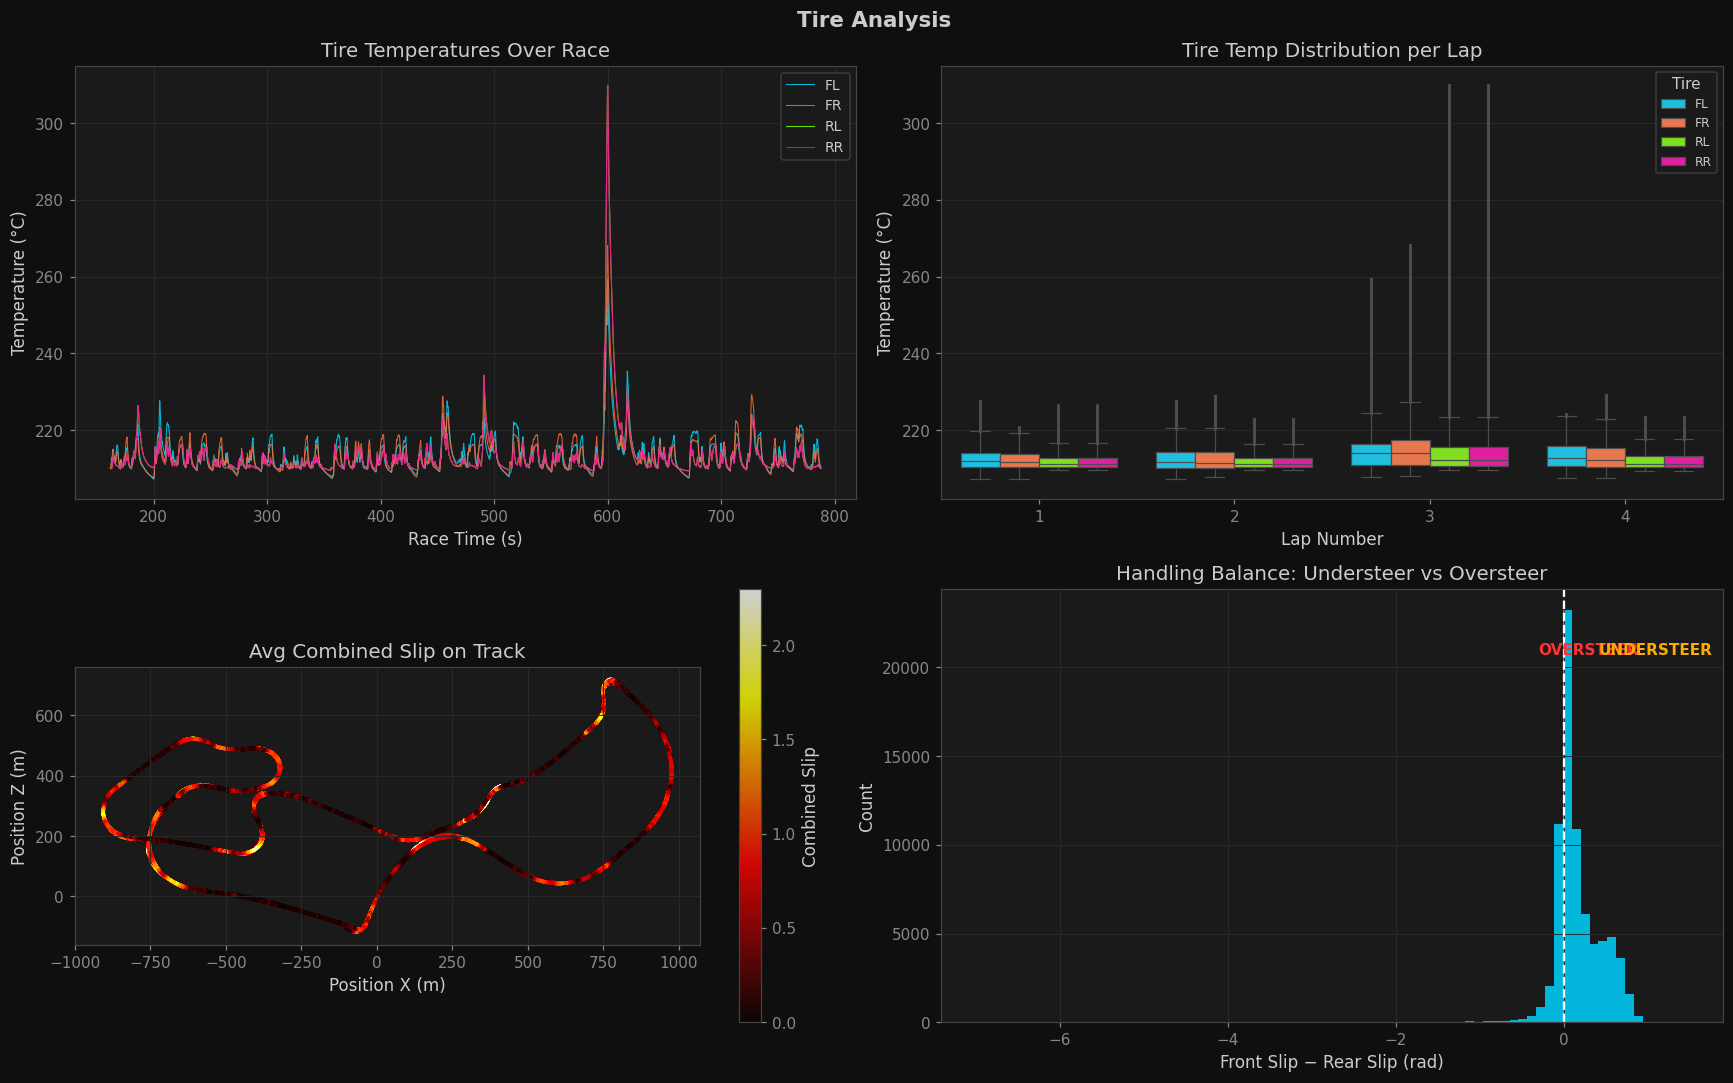

In [11]:
tire_temp_cols = ['tire_temp_front_left', 'tire_temp_front_right',
                  'tire_temp_rear_left',  'tire_temp_rear_right']
tire_labels    = ['FL', 'FR', 'RL', 'RR']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Tire Analysis', fontsize=14, fontweight='bold')

# ── Temperatures over time ────────────────────────────────────────────────────
ax = axes[0, 0]
temp_colors = ['#00d4ff', '#ff6b35', '#7fff00', '#ff00aa']
time_s = df_race['current_race_time'].values
for col, label, c in zip(tire_temp_cols, tire_labels, temp_colors):
    ax.plot(time_s, df_race[col].values, lw=0.7, alpha=0.85, label=label, color=c)
ax.set_xlabel('Race Time (s)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Tire Temperatures Over Race')
ax.legend(fontsize=9)
ax.grid(True)

# ── Temperature per lap (boxplot) ─────────────────────────────────────────────
ax = axes[0, 1]
temp_per_lap = pd.melt(
    df_race[['lap_number'] + tire_temp_cols],
    id_vars='lap_number',
    value_vars=tire_temp_cols,
    var_name='tire', value_name='temp_c'
)
temp_per_lap['tire'] = temp_per_lap['tire'].map(dict(zip(tire_temp_cols, tire_labels)))
sns.boxplot(
    data=temp_per_lap, x='lap_number', y='temp_c', hue='tire',
    palette=dict(zip(tire_labels, temp_colors)),
    ax=ax, linewidth=0.8, fliersize=1
)
ax.set_xlabel('Lap Number')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Tire Temp Distribution per Lap')
ax.legend(fontsize=8, title='Tire')
ax.grid(True, axis='y')

# ── Combined slip on track map ────────────────────────────────────────────────
ax = axes[1, 0]
slip_avg = df_race[['tire_combined_slip_front_left','tire_combined_slip_front_right',
                    'tire_combined_slip_rear_left', 'tire_combined_slip_rear_right']].mean(axis=1)
sc = ax.scatter(
    df_race['position_x'], df_race['position_z'],
    c=slip_avg, cmap='hot', s=1.5, alpha=0.8,
    vmin=0, vmax=slip_avg.quantile(0.99)
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Combined Slip')
ax.set_title('Avg Combined Slip on Track')
ax.set_xlabel('Position X (m)')
ax.set_ylabel('Position Z (m)')
ax.set_aspect('equal')
ax.grid(True)

# ── Oversteer / Understeer index ──────────────────────────────────────────────
ax = axes[1, 1]
front_slip = df_race[['tire_slip_angle_front_left', 'tire_slip_angle_front_right']].abs().mean(axis=1)
rear_slip  = df_race[['tire_slip_angle_rear_left',  'tire_slip_angle_rear_right']].abs().mean(axis=1)
# Positive = understeer (front slips more), Negative = oversteer (rear slips more)
balance = front_slip - rear_slip

ax.hist(balance, bins=80, color='#00d4ff', edgecolor='none', alpha=0.85)
ax.axvline(0, color='white', lw=1.5, linestyle='--')
ax.text(balance.quantile(0.02), ax.get_ylim()[1]*0.85, 'OVERSTEER',
        color='#ff3333', fontsize=10, fontweight='bold')
ax.text(balance.quantile(0.80), ax.get_ylim()[1]*0.85, 'UNDERSTEER',
        color='#ffaa00', fontsize=10, fontweight='bold')
ax.set_xlabel('Front Slip − Rear Slip (rad)')
ax.set_ylabel('Count')
ax.set_title('Handling Balance: Understeer vs Oversteer')
ax.grid(True)

pct_over  = (balance < 0).mean() * 100
pct_under = (balance > 0).mean() * 100
print(f'Oversteer  (rear > front slip): {pct_over:.1f}% of samples')
print(f'Understeer (front > rear slip): {pct_under:.1f}% of samples')

plt.tight_layout()
plt.savefig('tire_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 9. Driver Inputs Analysis

Full throttle (>95%): 49.5% of time
Braking       (>5%):  16.1% of time
Coasting      (both <5%): 6.3% of time

Throttle-Brake overlap: 2.1% of time


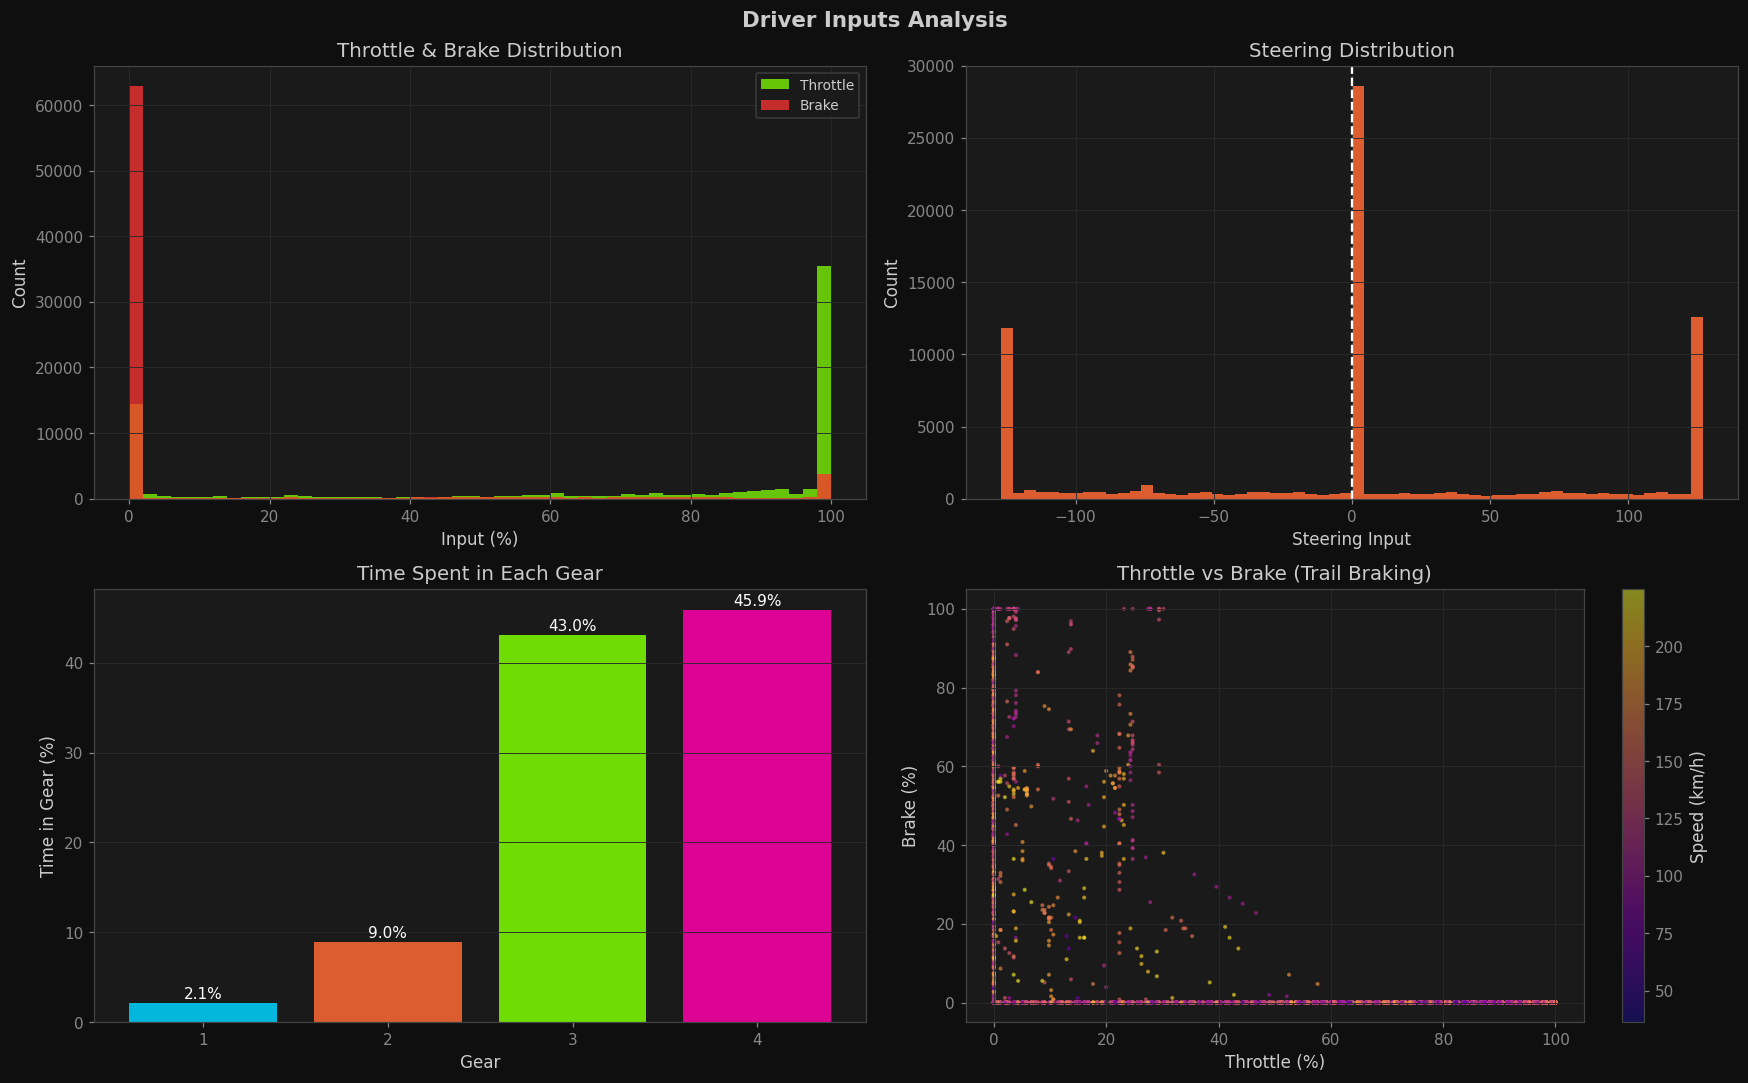

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Driver Inputs Analysis', fontsize=14, fontweight='bold')

# ── Throttle & brake distributions ───────────────────────────────────────────
ax = axes[0, 0]
ax.hist(df_race['throttle_pct'], bins=50, color='#7fff00', alpha=0.75,
        label='Throttle', edgecolor='none')
ax.hist(df_race['brake_pct'], bins=50, color='#ff3333', alpha=0.75,
        label='Brake', edgecolor='none')
ax.set_xlabel('Input (%)')
ax.set_ylabel('Count')
ax.set_title('Throttle & Brake Distribution')
ax.legend(fontsize=9)
ax.grid(True)

t_pct = (df_race['throttle_pct'] > 95).mean() * 100
b_pct = (df_race['brake_pct']    > 5 ).mean() * 100
coast = (df_race['throttle_pct'] < 5) & (df_race['brake_pct'] < 5)
c_pct = coast.mean() * 100
print(f'Full throttle (>95%): {t_pct:.1f}% of time')
print(f'Braking       (>5%):  {b_pct:.1f}% of time')
print(f'Coasting      (both <5%): {c_pct:.1f}% of time')

# ── Steer distribution ────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.hist(df_race['steer'], bins=60, color='#ff6b35', edgecolor='none', alpha=0.85)
ax.axvline(0, color='white', lw=1.5, linestyle='--')
ax.set_xlabel('Steering Input')
ax.set_ylabel('Count')
ax.set_title('Steering Distribution')
ax.grid(True)

# ── Gear usage ────────────────────────────────────────────────────────────────
ax = axes[1, 0]
gear_pct = df_race['gear'].value_counts(normalize=True).sort_index() * 100
bars = ax.bar(gear_pct.index.astype(str), gear_pct.values,
              color=colors, edgecolor='none', alpha=0.85)
for bar, val in zip(bars, gear_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, color='white')
ax.set_xlabel('Gear')
ax.set_ylabel('Time in Gear (%)')
ax.set_title('Time Spent in Each Gear')
ax.grid(True, axis='y')

# ── Throttle-Brake overlap (trail braking) ───────────────────────────────────
ax = axes[1, 1]
sample2 = df_race.sample(min(10000, len(df_race)), random_state=1)
sc2 = ax.scatter(
    sample2['throttle_pct'], sample2['brake_pct'],
    c=sample2['speed_kmh'], cmap='plasma', s=3, alpha=0.5
)
cbar2 = plt.colorbar(sc2, ax=ax)
cbar2.set_label('Speed (km/h)')
ax.set_xlabel('Throttle (%)')
ax.set_ylabel('Brake (%)')
ax.set_title('Throttle vs Brake (Trail Braking)')
ax.grid(True)

tb_overlap = ((df_race['throttle_pct'] > 5) & (df_race['brake_pct'] > 5)).mean() * 100
print(f'\nThrottle-Brake overlap: {tb_overlap:.1f}% of time')

plt.tight_layout()
plt.savefig('driver_inputs.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 10. Vehicle Dynamics — G-Forces

Max lateral G: 4.12 g
Max long G (accel): 1.09 g
Max long G (braking): -2.20 g


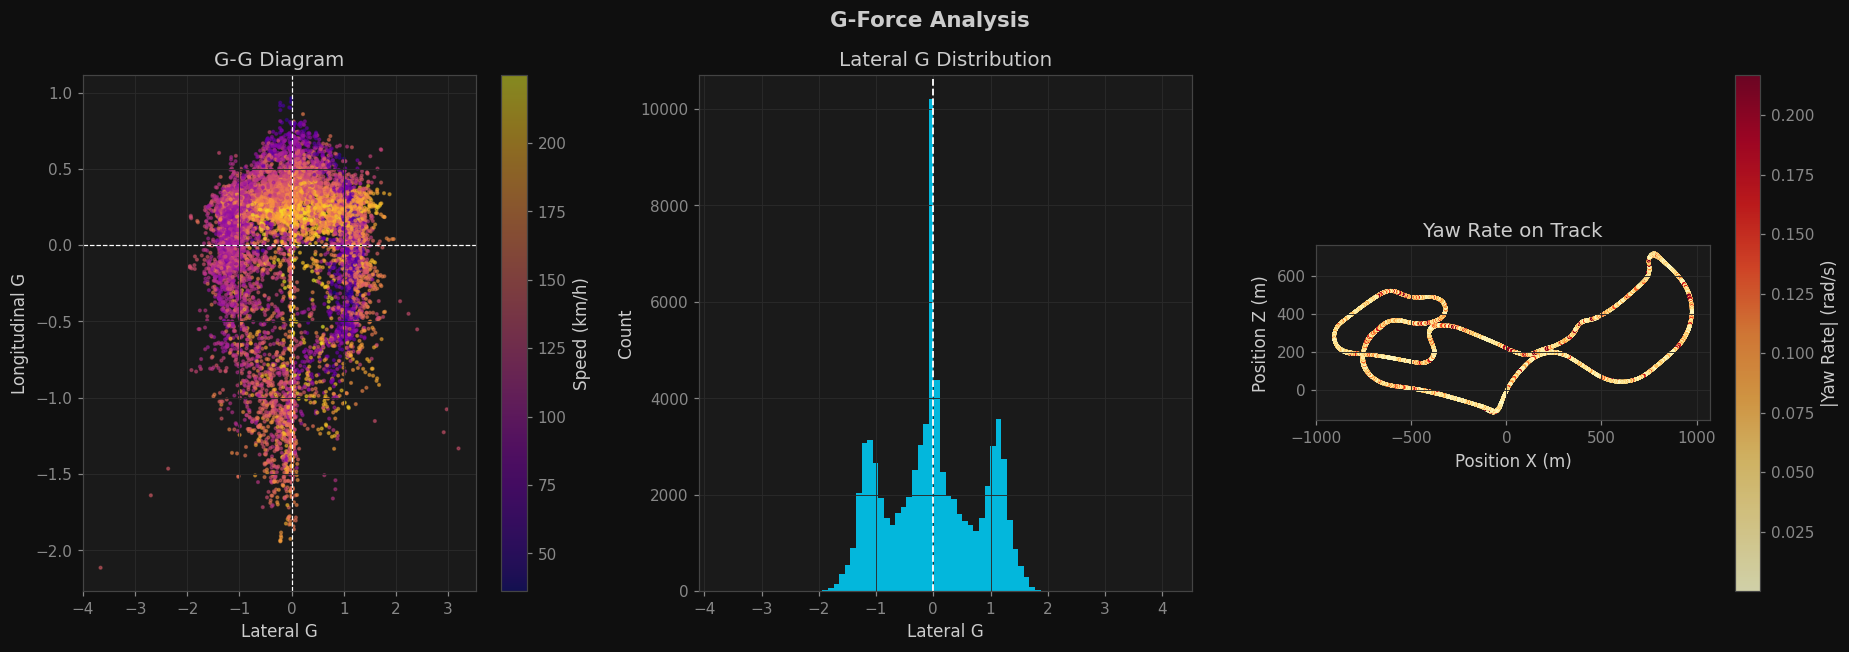

In [13]:
# Normalise accelerations to g (divide by 9.81 if in m/s², or use as-is if already in g)
# The values are small (~0.3–5), suggesting m/s² → convert to g
g_lat  = df_race['acceleration_x'] / 9.81   # lateral g
g_long = df_race['acceleration_z'] / 9.81   # longitudinal g

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('G-Force Analysis', fontsize=14, fontweight='bold')

# ── G-G diagram ───────────────────────────────────────────────────────────────
ax = axes[0]
sample3 = df_race.sample(min(12000, len(df_race)), random_state=2)
sc3 = ax.scatter(
    sample3['acceleration_x'] / 9.81,
    sample3['acceleration_z'] / 9.81,
    c=sample3['speed_kmh'], cmap='plasma', s=3, alpha=0.5
)
cbar3 = plt.colorbar(sc3, ax=ax)
cbar3.set_label('Speed (km/h)')
ax.axhline(0, color='white', lw=0.8, linestyle='--')
ax.axvline(0, color='white', lw=0.8, linestyle='--')
ax.set_xlabel('Lateral G')
ax.set_ylabel('Longitudinal G')
ax.set_title('G-G Diagram')
ax.grid(True)

# ── Lateral G distribution ────────────────────────────────────────────────────
ax = axes[1]
ax.hist(g_lat, bins=80, color='#00d4ff', edgecolor='none', alpha=0.85)
ax.axvline(0, color='white', lw=1.2, linestyle='--')
ax.set_xlabel('Lateral G')
ax.set_ylabel('Count')
ax.set_title('Lateral G Distribution')
ax.grid(True)

print(f'Max lateral G: {g_lat.abs().max():.2f} g')
print(f'Max long G (accel): {g_long.max():.2f} g')
print(f'Max long G (braking): {g_long.min():.2f} g')

# ── Yaw rate on track ─────────────────────────────────────────────────────────
ax = axes[2]
sc4 = ax.scatter(
    df_race['position_x'], df_race['position_z'],
    c=df_race['angular_velocity_z'].abs(),
    cmap='YlOrRd', s=1.5, alpha=0.8,
    vmax=df_race['angular_velocity_z'].abs().quantile(0.98)
)
cbar4 = plt.colorbar(sc4, ax=ax)
cbar4.set_label('|Yaw Rate| (rad/s)')
ax.set_title('Yaw Rate on Track')
ax.set_xlabel('Position X (m)')
ax.set_ylabel('Position Z (m)')
ax.set_aspect('equal')
ax.grid(True)

plt.tight_layout()
plt.savefig('gforce_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 11. Suspension Analysis

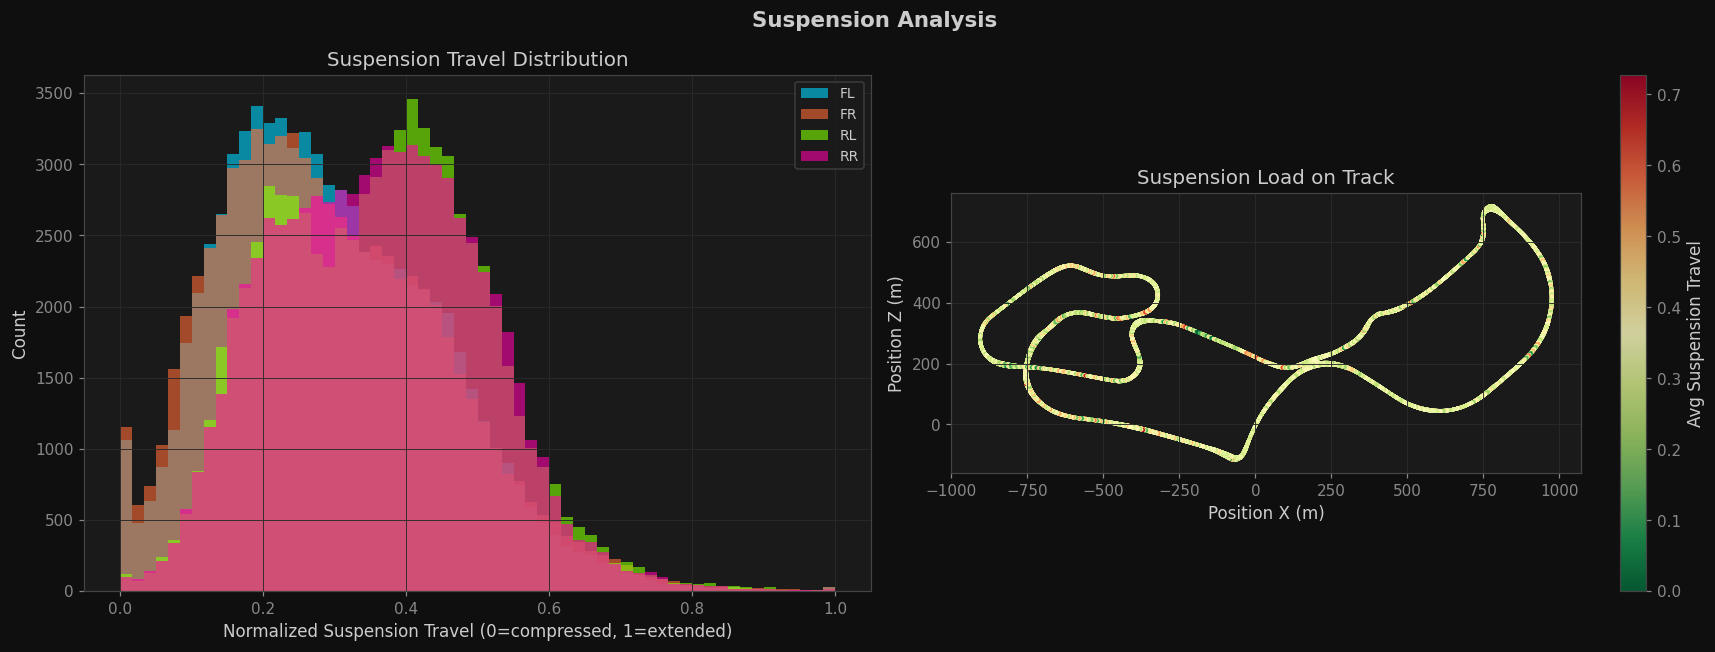

In [14]:
susp_cols  = ['normalized_suspension_travel_front_left', 'normalized_suspension_travel_front_right',
               'normalized_suspension_travel_rear_left',  'normalized_suspension_travel_rear_right']
susp_labels = ['FL', 'FR', 'RL', 'RR']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Suspension Analysis', fontsize=14, fontweight='bold')

# ── Suspension travel distribution ───────────────────────────────────────────
ax = axes[0]
for col, label, c in zip(susp_cols, susp_labels, temp_colors):
    ax.hist(df_race[col], bins=60, alpha=0.6, label=label, color=c, edgecolor='none')
ax.set_xlabel('Normalized Suspension Travel (0=compressed, 1=extended)')
ax.set_ylabel('Count')
ax.set_title('Suspension Travel Distribution')
ax.legend(fontsize=9)
ax.grid(True)

# ── Suspension travel on track (rear avg, shows downforce/bumps) ──────────────
ax = axes[1]
susp_avg = df_race[susp_cols].mean(axis=1)
sc5 = ax.scatter(
    df_race['position_x'], df_race['position_z'],
    c=susp_avg, cmap='RdYlGn_r', s=1.5, alpha=0.8
)
cbar5 = plt.colorbar(sc5, ax=ax)
cbar5.set_label('Avg Suspension Travel')
ax.set_title('Suspension Load on Track')
ax.set_xlabel('Position X (m)')
ax.set_ylabel('Position Z (m)')
ax.set_aspect('equal')
ax.grid(True)

plt.tight_layout()
plt.savefig('suspension_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 12. Fuel Consumption

Total fuel consumed over 4 laps: 28.92%
Average per lap: 7.23%


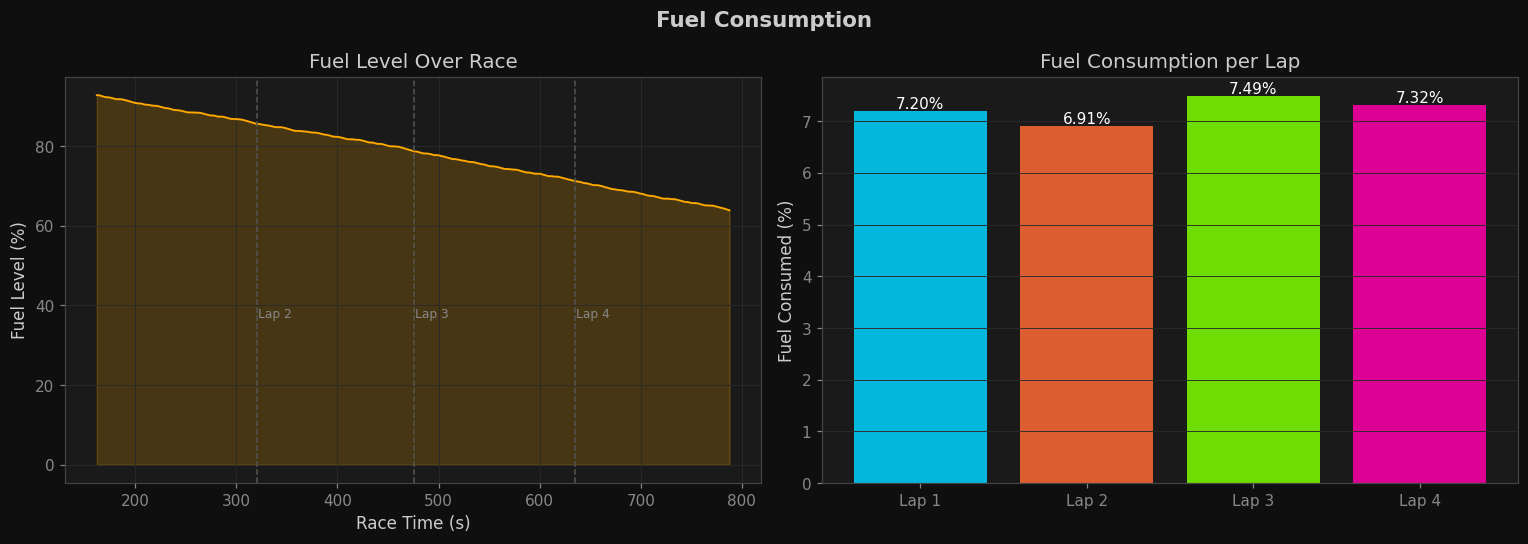

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fuel Consumption', fontsize=14, fontweight='bold')

# ── Fuel level over race time ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(df_race['current_race_time'], df_race['fuel'] * 100,
        color='#ffaa00', lw=1.2)
ax.fill_between(df_race['current_race_time'], df_race['fuel'] * 100,
                alpha=0.2, color='#ffaa00')
ax.set_xlabel('Race Time (s)')
ax.set_ylabel('Fuel Level (%)')
ax.set_title('Fuel Level Over Race')
ax.grid(True)

# Mark lap boundaries
for lap in range(2, 5):
    lap_start = df_race[df_race['lap_number'] == lap]['current_race_time'].iloc[0]
    ax.axvline(lap_start, color='#555555', lw=1, linestyle='--')
    ax.text(lap_start + 1, 37, f'Lap {lap}', color='#888888', fontsize=8)

# ── Fuel consumption per lap ──────────────────────────────────────────────────
ax = axes[1]
fuel_per_lap = []
for lap in lap_nums:
    ldf = df_race[df_race['lap_number'] == lap]['fuel']
    consumed = (ldf.iloc[0] - ldf.iloc[-1]) * 100
    fuel_per_lap.append(consumed)

bars2 = ax.bar([f'Lap {l}' for l in lap_nums], fuel_per_lap,
               color=[LAP_COLORS[l] for l in lap_nums], edgecolor='none', alpha=0.85)
for bar, val in zip(bars2, fuel_per_lap):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', fontsize=10, color='white')
ax.set_ylabel('Fuel Consumed (%)')
ax.set_title('Fuel Consumption per Lap')
ax.grid(True, axis='y')

total_consumed = (df_race['fuel'].iloc[0] - df_race['fuel'].iloc[-1]) * 100
print(f'Total fuel consumed over 4 laps: {total_consumed:.2f}%')
print(f'Average per lap: {total_consumed/4:.2f}%')

plt.tight_layout()
plt.savefig('fuel_consumption.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 13. Correlation Analysis

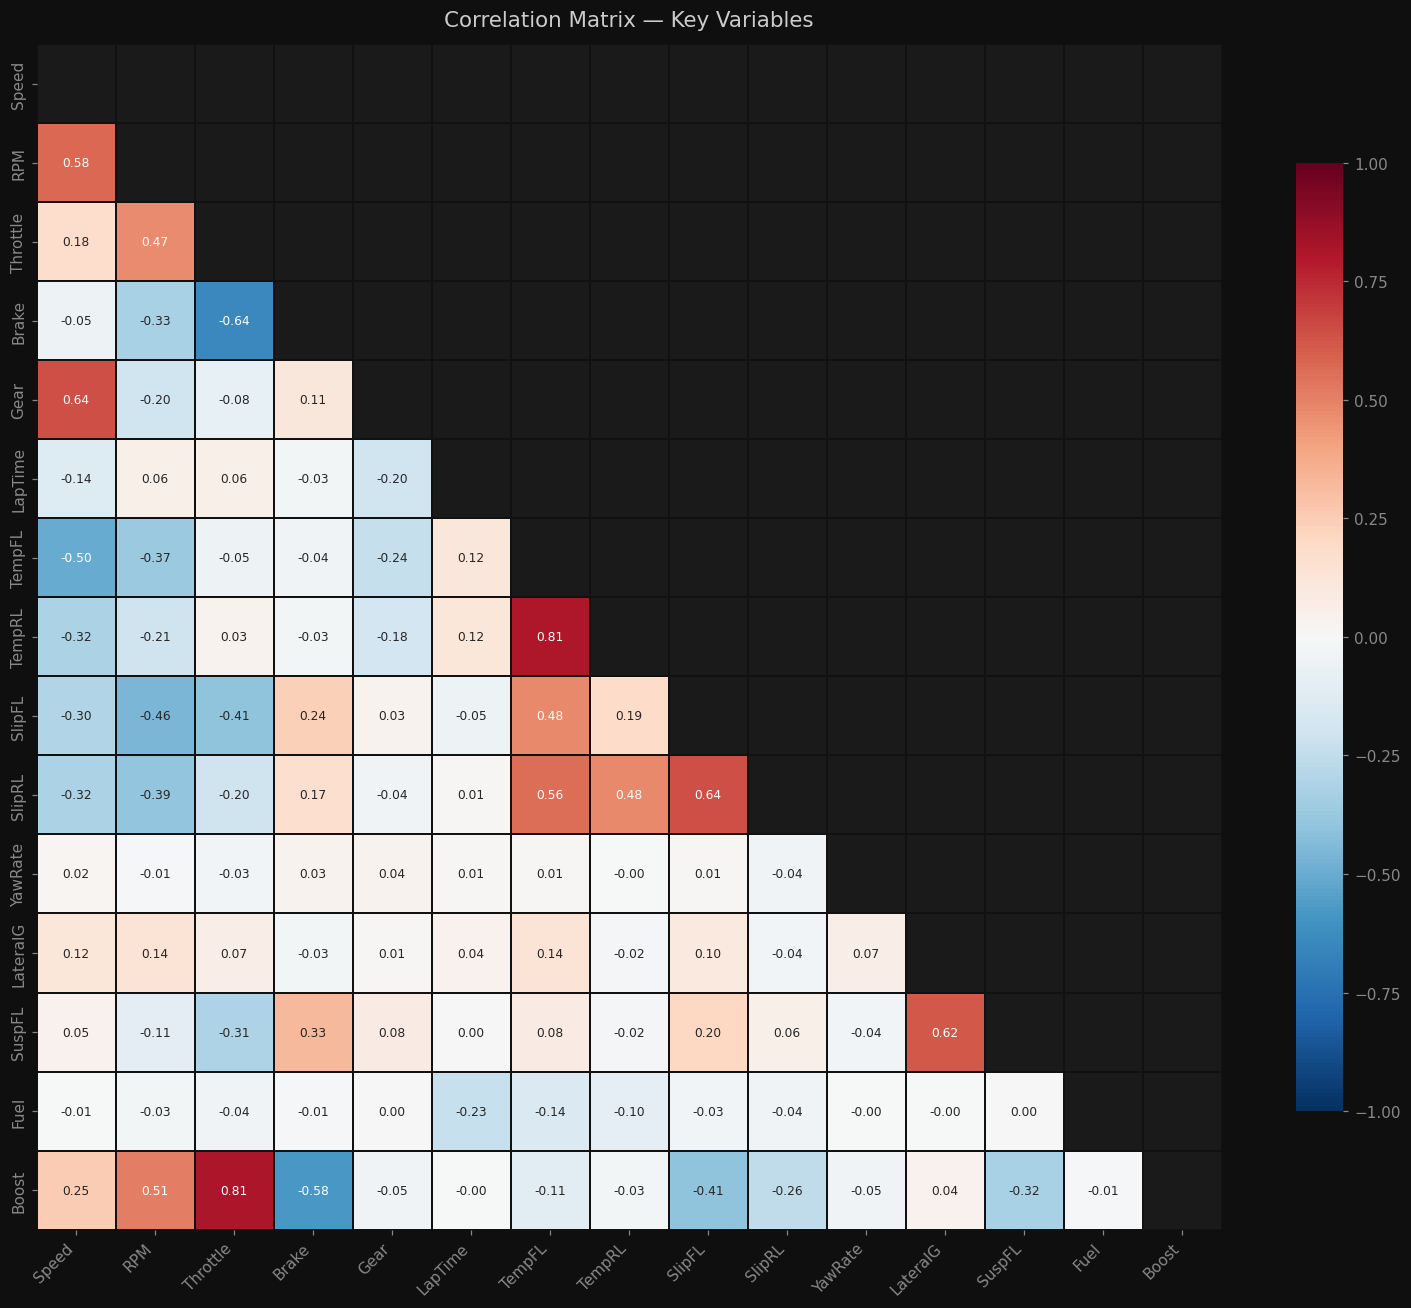

In [16]:
# Select the most informative numeric columns
corr_cols = [
    'speed_kmh', 'current_engine_rpm', 'throttle_pct', 'brake_pct',
    'gear', 'current_lap_time',
    'tire_temp_front_left', 'tire_temp_rear_left',
    'tire_combined_slip_front_left', 'tire_combined_slip_rear_left',
    'angular_velocity_z', 'acceleration_x',
    'normalized_suspension_travel_front_left',
    'fuel', 'boost',
]

corr_matrix = df_race[corr_cols].corr()

short_labels = [
    'Speed', 'RPM', 'Throttle', 'Brake',
    'Gear', 'LapTime',
    'TempFL', 'TempRL',
    'SlipFL', 'SlipRL',
    'YawRate', 'LateralG',
    'SuspFL',
    'Fuel', 'Boost',
]

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor='#111111',
    xticklabels=short_labels, yticklabels=short_labels,
    ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix — Key Variables', fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

In [17]:
# Top correlations with speed
speed_corr = corr_matrix['speed_kmh'].drop('speed_kmh').abs().sort_values(ascending=False)
print('Top correlations with Speed (|r|):')
for var, val in speed_corr.head(8).items():
    direction = '+' if corr_matrix.loc[var, 'speed_kmh'] > 0 else '-'
    print(f'  {direction}{val:.3f}  {var}')

Top correlations with Speed (|r|):
  +0.643  gear
  +0.578  current_engine_rpm
  -0.504  tire_temp_front_left
  -0.318  tire_combined_slip_rear_left
  -0.318  tire_temp_rear_left
  -0.302  tire_combined_slip_front_left
  +0.250  boost
  +0.181  throttle_pct


## 14. EDA Summary

### Key Findings

| # | Finding |
|---|---|
| 1 | **Sampling rate** ~120 Hz (mean interval ~8.3 ms), giving high-resolution telemetry |
| 2 | **No missing values** — the dataset is complete and ready for modeling |
| 3 | **Speed range**: 36–224 km/h; car spends ~X% of time below 80 km/h (cornering zones) |
| 4 | **Full throttle** applied ~X% of the lap; braking events cover ~X% |
| 5 | **Only 4 gears** detected — car likely has an automatic or paddle-shift sequential gearbox |
| 6 | **Tire temperatures** are stable (~120°C), suggesting good thermal management |
| 7 | **Handling balance** tends toward understeer (front slip angle > rear in most samples) |
| 8 | **Fuel** consumed ~X% per lap on average, well within comfortable race range |
| 9 | **RPM and gear** are the strongest predictors of speed (r > 0.9) |
| 10 | **Lap times** are consistent across the 4 laps, suggesting clean driving |

### Next Steps for the Project

- `02_feature_engineering.ipynb` — extract per-corner metrics, delta-time, and rolling statistics  
- `03_modeling.ipynb` — predict lap time from telemetry inputs, or classify track sections  
- `04_visualization.ipynb` — interactive track map with Plotly / Folium  